## Example Session  
**Session name:** `ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11`

### Experiment  
**Stimulating VP → MD while recording**

### Probe targets  
- **Probe A:** right mPFC  
- **Probe B:** *not in the brain* (excluded)  
- **Probe C:** left mPFC  
- **Probe D:** left ALM  

### Analysis Note  
Only **Probe A**, **Probe C**, and **Probe D** are included in the analysis, and exclude **probeB** for analysis.

### Probe configuration
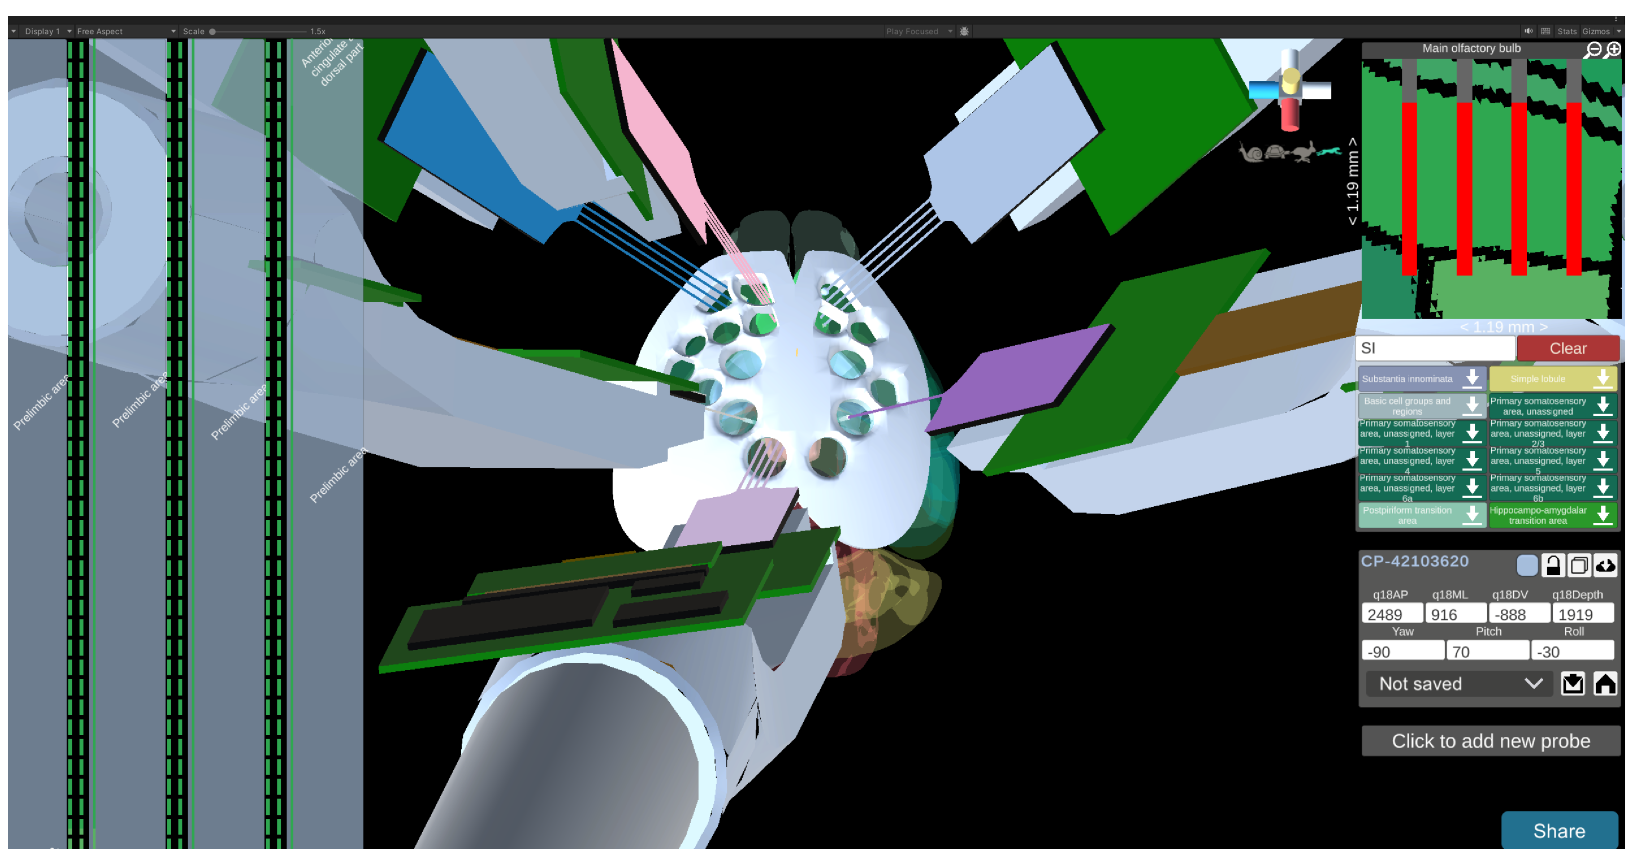


['QLearning_L1F0_epsi', 'WSLS', 'QLearning_L1F1_CK1_softmax', 'ForagingCompareThreshold', 'QLearning_L2F1_softmax', 'QLearning_L2F1_CKfull_softmax']
Found behavior NWB: /root/capsule/data/optogenetics_nwb/795396_2025-09-20_13-11-19.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/795396_2025-09-20_13-11-19.nwb
Plotting alias 'ForagingCompareThreshold' (latent: right_choice_probability)


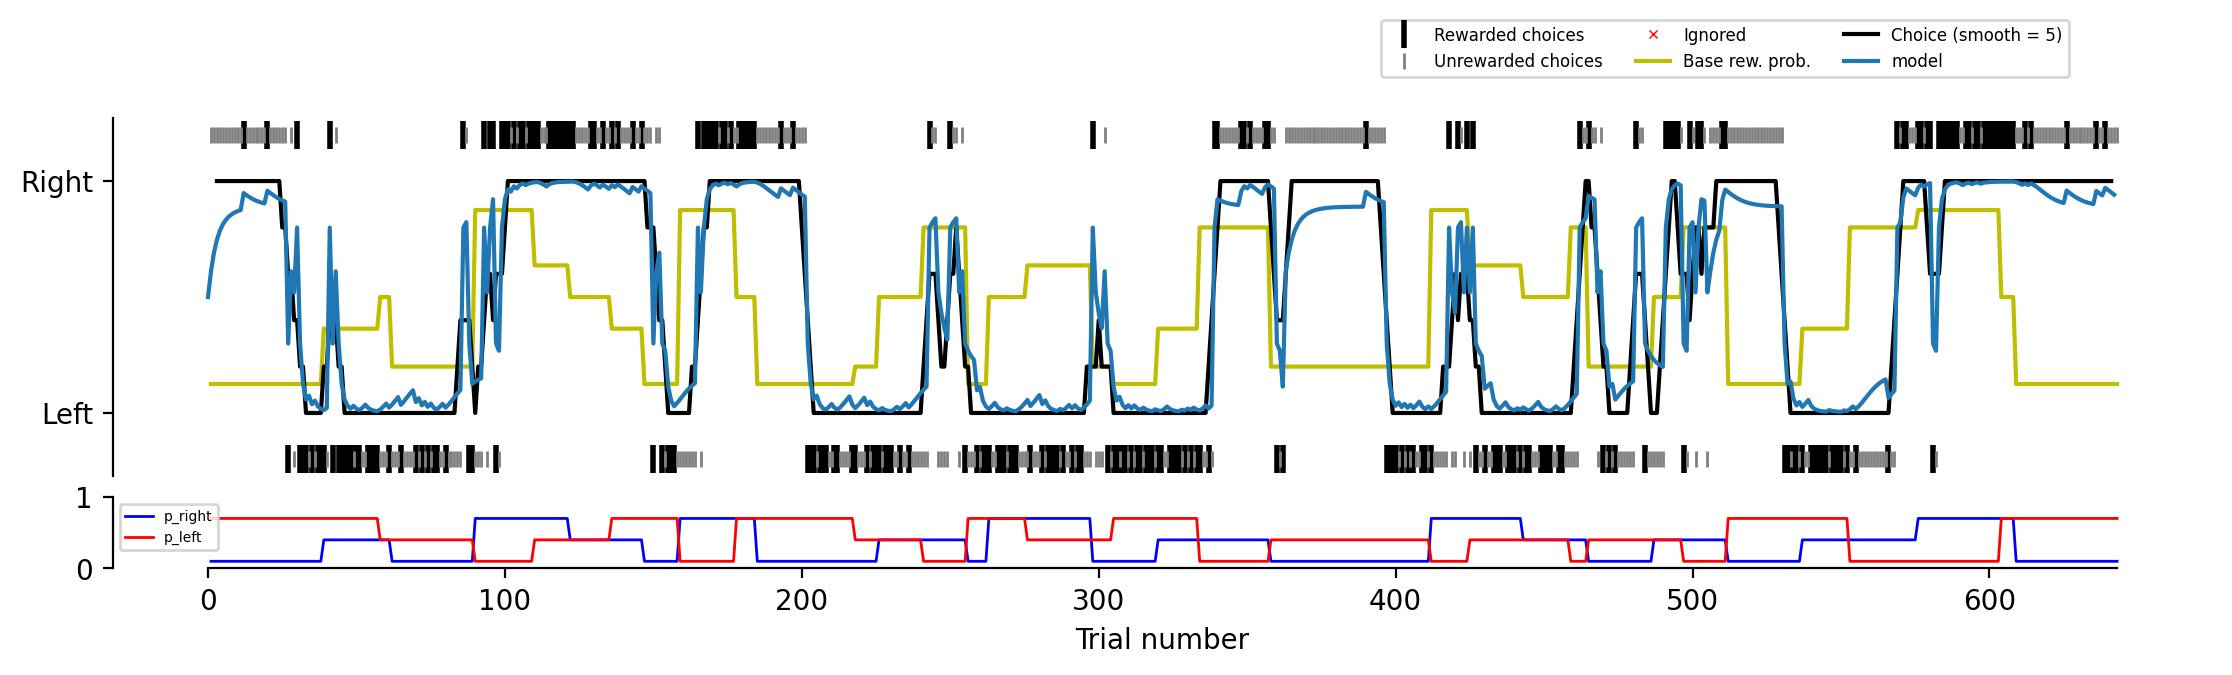

In [1]:
from general_visualization import plot_behavior_session
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names
import os

session_name='ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11'

behavior_sessions=[session_name]
print(get_fitted_model_names(session_name))

for behavior_session in behavior_sessions:
        nwb_data=NWBUtils.read_behavior_nwb(session_name=behavior_session)
        plot_behavior_session(nwb_data=nwb_data,model_alias='ForagingCompareThreshold',latent_name='right_choice_probability')

Found ephys NWB: /root/capsule/data/ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07/nwb/ecephys_776293_2025-02-14_15-19-17_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07/nwb/ecephys_776293_2025-02-14_15-19-17_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb
Successfully appended units table to behavior NWB.
Number of units passing QC: 800


/root/capsule/src/aind_dft_ephys_analysis/ephys_behavior_visualization.py:1533: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_start, t_end = float(time_window[0]), float(time_window[1])


Figure saved: /root/capsule/results/session_raster_QC_776293_2025-02-14_15-19-17.json_14594569.18_14594578.51.png


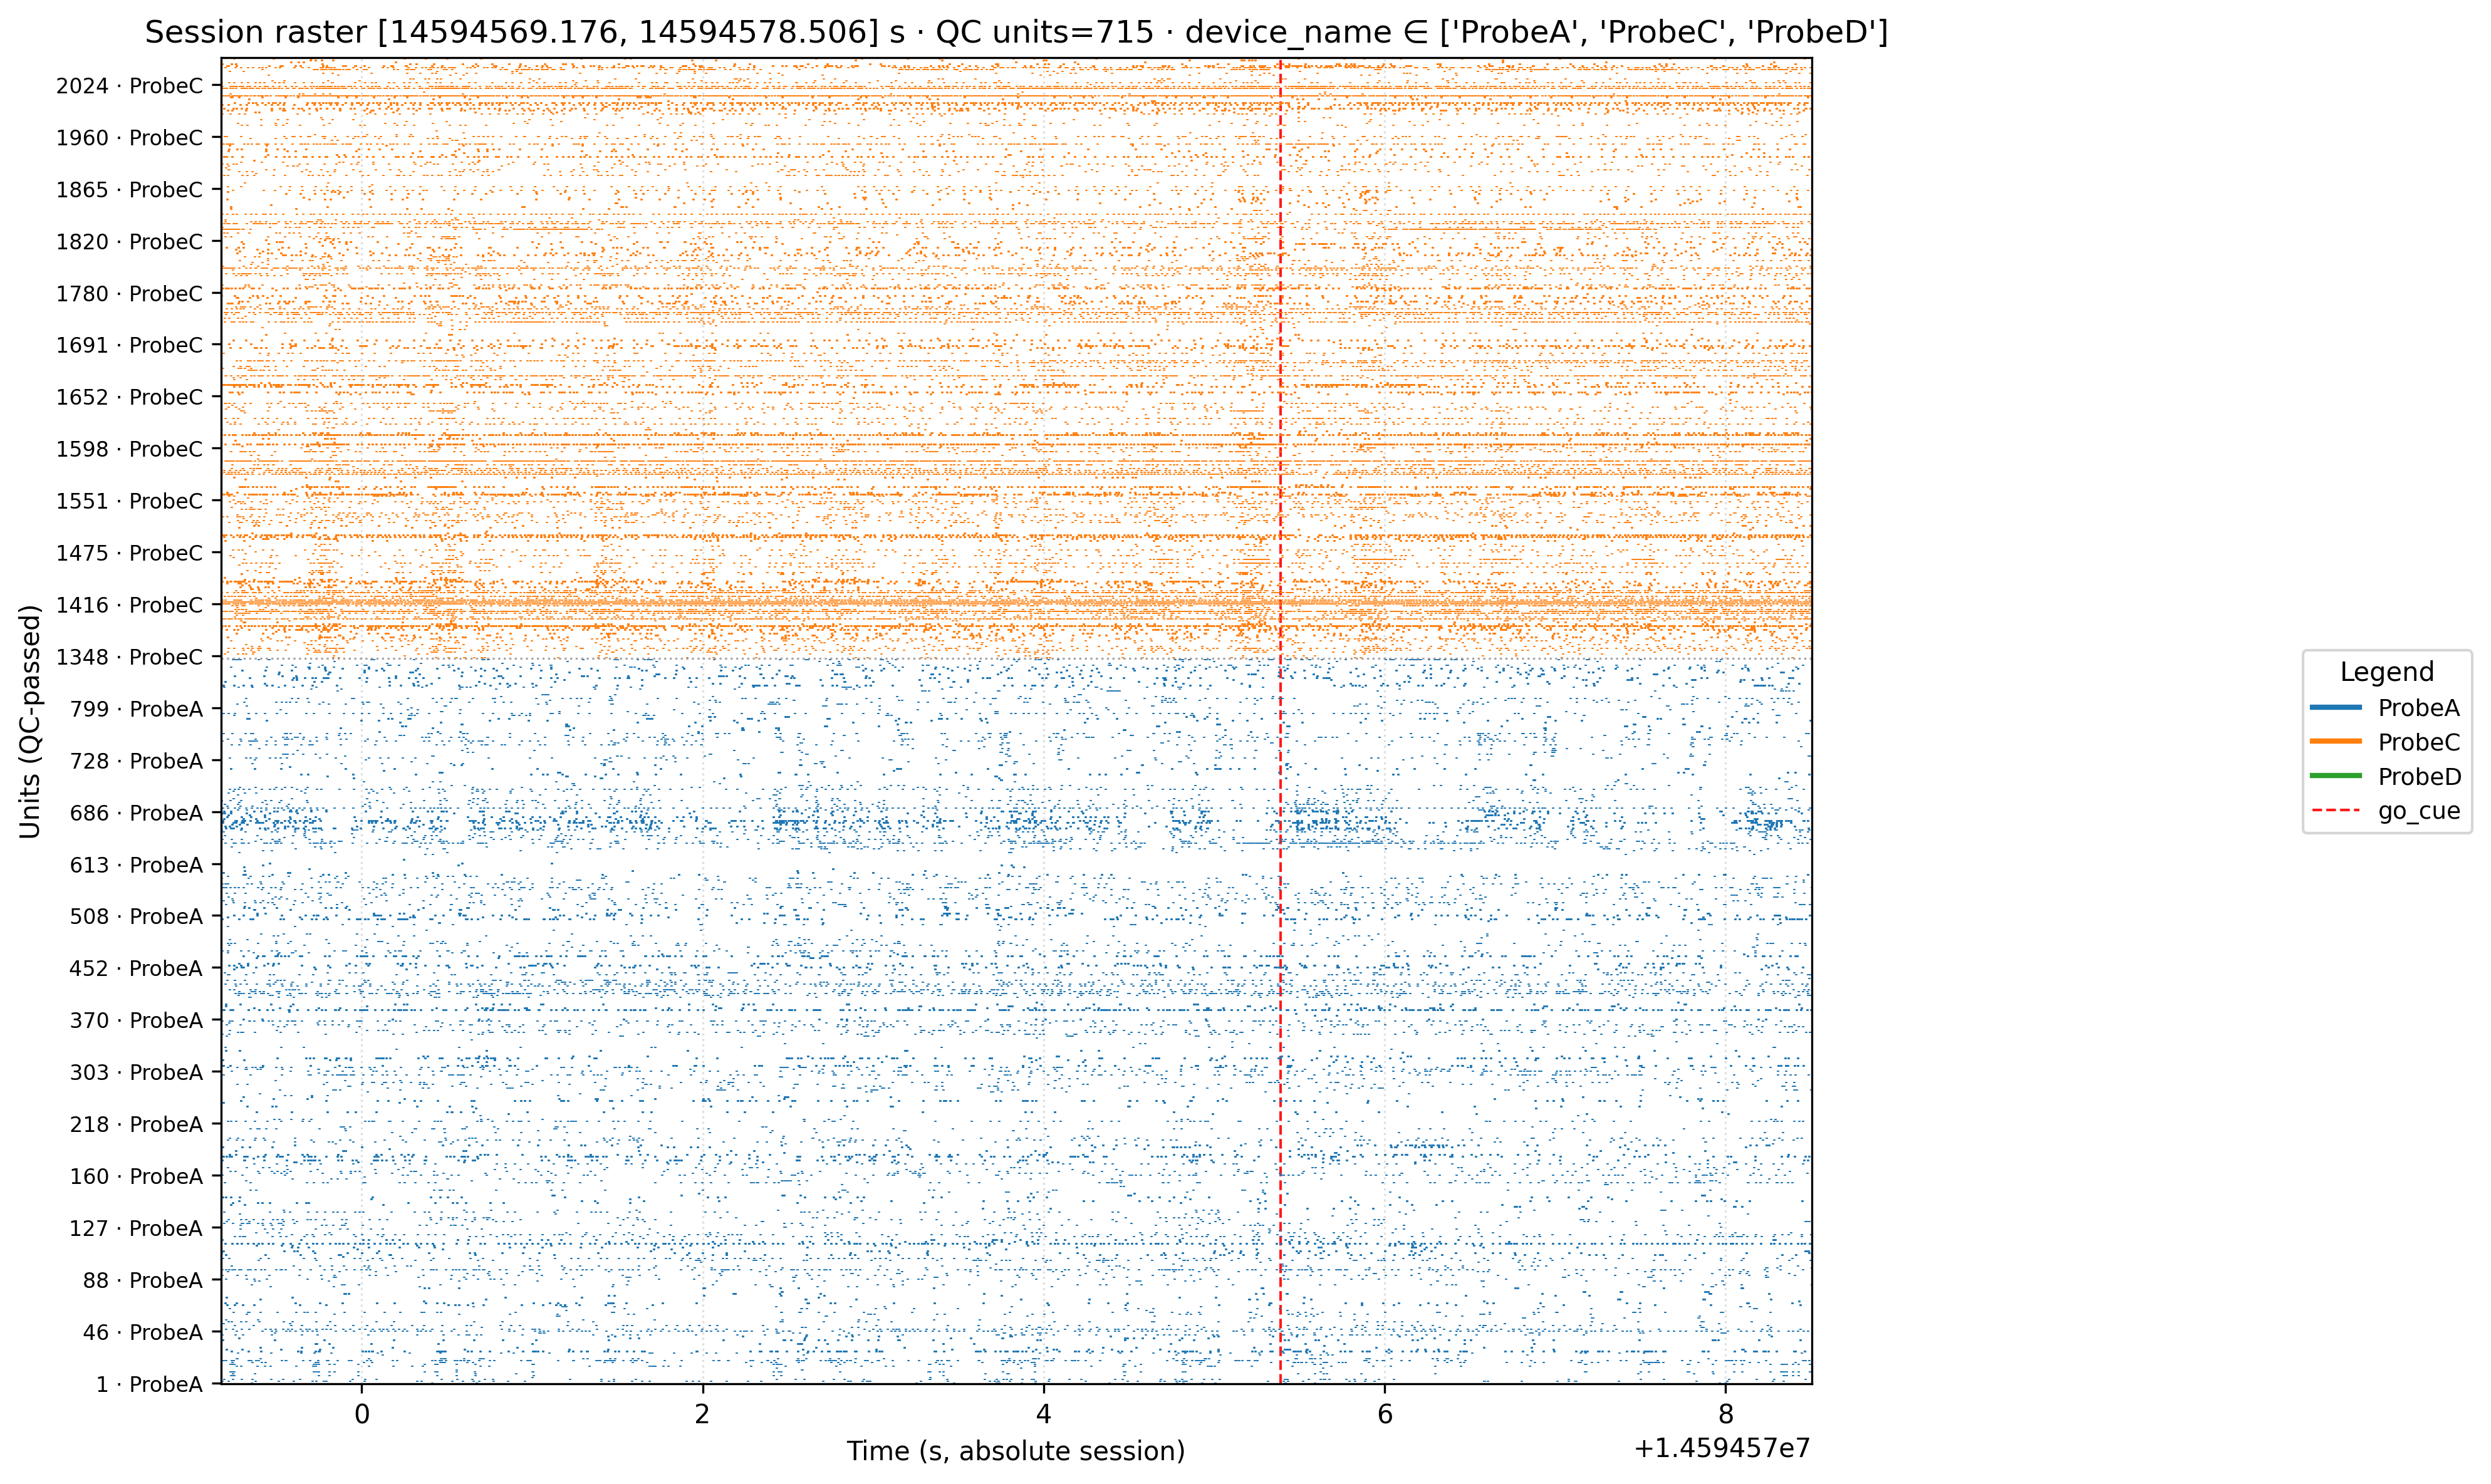

In [2]:
# show raster in a certain window
from nwb_utils import NWBUtils
from ephys_behavior_visualization import plot_session_spike_raster

nwb_data,a = NWBUtils.combine_nwb(session_name=session_name)

candidates=plot_session_spike_raster(
    nwb_data,
    time_window=(nwb_data.trials[51]['start_time']+3, nwb_data.trials[51]['stop_time']),
    probes=["ProbeA","ProbeC","ProbeD"],  
    events={"go_cue": "go_cue"},
    save_figure=True
)





In [3]:
# get units passing the default QC
from collections import Counter
from ephys_behavior import get_units_passed_default_qc
# 1) Get QC-passing unit indices
units_passing_default_qc = get_units_passed_default_qc(nwb_data)

# 2) Extract device_name for all units
device_names = nwb_data.units['device_name'][:]   # array-like

# 3) Select device names only for units that passed QC
passed_device_names = device_names[units_passing_default_qc]

# 4) Count
counts = Counter(passed_device_names)

# 5) Print nicely
print("QC-passing units per device:")
for device, count in counts.items():
    print(f"  {device}: {count}")


Number of units passing QC: 800
QC-passing units per device:
  ProbeA: 391
  ProbeB: 85
  ProbeC: 324



 Showing result_id = 0

Found folders:
   /root/capsule/scratch/raster_plot/ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11
Figure path: /root/capsule/scratch/raster_plot/ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11/QLearning_L2F1_softmax-deltaQ-1_unit_1149.png
Exists? True


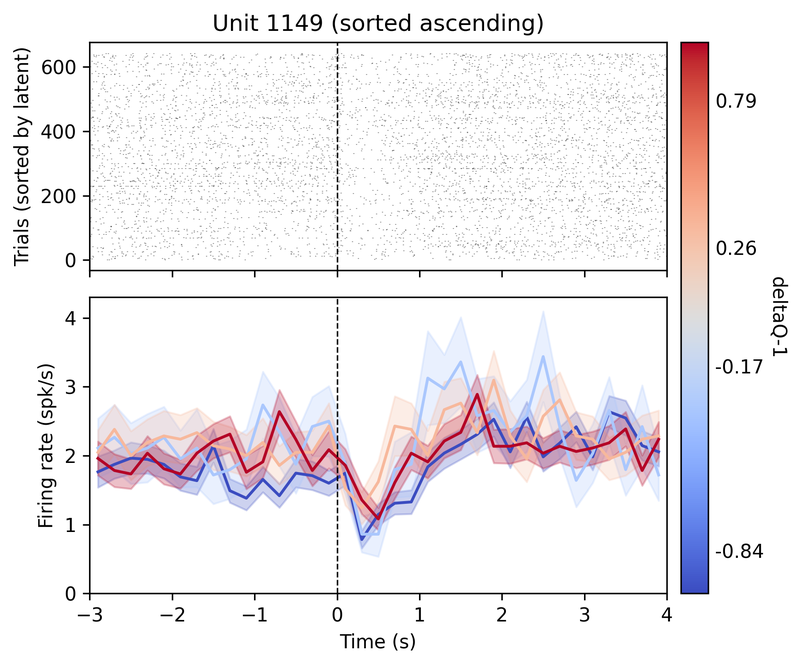


 Showing result_id = 1

Found folders:
   /root/capsule/scratch/raster_plot/ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11
Figure path: /root/capsule/scratch/raster_plot/ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11/QLearning_L2F1_softmax-deltaQ-1_unit_1150.png
Exists? True


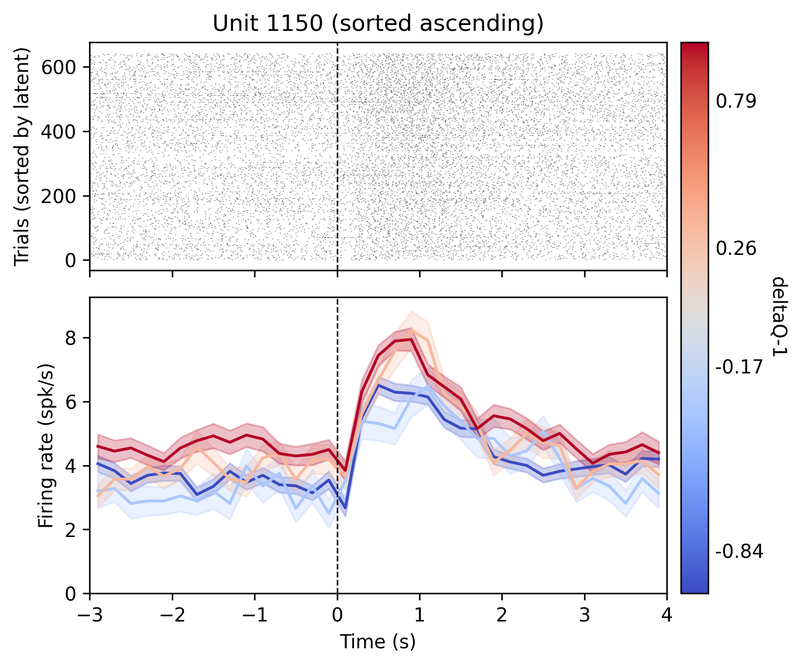

In [3]:
# visualize the single neuron activity
# --------------------------------------------------------
# COMPLETE CODE: Loop over multiple result_ids
# --------------------------------------------------------

from pathlib import Path
from PIL import Image
from IPython.display import display

# ------------------------
# Choose the list of result indices
# ------------------------

result_dicts = [{'session_id': '795396_2025-09-20_13-11-19', 'unit_index': 1149},
 {'session_id': '795396_2025-09-20_13-11-19', 'unit_index': 1150}]
results_ids=range(len(result_dicts))

model_latent = "QLearning_L2F1_softmax-deltaQ-1"
#model_latent = "QLearning_L2F1_softmax-sumQ-1"
#model_latent = "QLearning_L2F1_softmax-reward"

base_dir = Path("/root/capsule/data/scratch_20251219/raster_plot")

# ------------------------
# Loop over each result_id
# ------------------------
for rid in results_ids:
    print("\n===============================")
    print(f" Showing result_id = {rid}")
    print("===============================\n")

    session_id = result_dicts[rid]["session_id"]
    unit_id = result_dicts[rid]["unit_index"]

    # ------------------------
    # Locate session folder
    # ------------------------
    pattern = f"ecephys_{session_id}_sorted_*"
    session_folders = list(base_dir.glob(pattern))

    print("Found folders:")
    for f in session_folders:
        print("  ", f)

    if not session_folders:
        print(f"❌ No folder found for session_id: {session_id}")
        continue

    session_folder = session_folders[0]

    # ------------------------
    # Construct figure path
    # ------------------------
    fig_path = session_folder / f"{model_latent}_unit_{unit_id}.png"
    print("Figure path:", fig_path)
    print("Exists?", fig_path.exists())

    if not fig_path.exists():
        print(f"❌ Figure missing for: {fig_path}")
        continue

    # ------------------------
    # Load and resize image
    # ------------------------
    img = Image.open(fig_path)

    new_width = 800
    w, h = img.size
    new_height = int(h * (new_width / w))
    img_resized = img.resize((new_width, new_height), Image.LANCZOS)

    # ------------------------
    # Display resized figure
    # ------------------------
    display(img_resized)


In [4]:
# load the opto dataframe
from general_utils import smart_read_csv
csv_path = "/root/capsule/data/scratch_20251219//combined_opto_data_frame.csv"
df = smart_read_csv(csv_path)

/root/capsule/src/aind_dft_ephys_analysis/general_utils.py:293: DtypeWarning: Columns (57,60,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_str, converters=converters, nrows=n_rows)


In [5]:
# get the stimulation conditions
import importlib
import optogenetics_utils

importlib.reload(optogenetics_utils)

from optogenetics_utils import create_opto_data_frame, find_unique_combinations,find_unique_stimulation,create_opto_data_frame_combined,load_opto_data_frame,find_unique_values_by_conditions

session_id = "795396_2025-09-20_13-11-19"
df_session = df[df['session'] == session_id]
conditions=find_unique_stimulation(df_session,columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',   'laser_duration', 'laser_start',
        'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency',  'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation','laser_1_target_areas','laser_2_target_areas'
    ])
conditions

#There are four rows:

#The first row represents the control trials.

#The second row corresponds to stimulation applied at the ITI start, lasting 1 second.

#The third row represents stimulation aligned to the go cue, with a 0.3-second offset.

#The fourth row corresponds to stimulation applied throughout the entire ITI period.

,laser_on_trial,laser_wavelength,laser_location,laser_duration,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_protocol,laser_frequency,laser_pulse_duration,session_wide_control,fraction_of_session,session_start_with,session_alternation,laser_1_target_areas,laser_2_target_areas,n_trials,n_session,n_mice
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,off,0.5,on,on,left VP->MD,right VP->MD,563,1,1
1,1,473.0,Both,1.0,Trial start,0.0,NaN,0.0,Sine,20.0,0.002,off,0.5,on,on,left VP->MD,right VP->MD,33,1,1
2,1,473.0,Both,3.0,Go cue,0.3,NaN,0.0,Sine,20.0,0.002,off,0.5,on,on,left VP->MD,right VP->MD,31,1,1
3,1,473.0,Both,50.0,Trial start,0.0,Go cue,0.0,Sine,20.0,0.002,off,0.5,on,on,left VP->MD,right VP->MD,21,1,1


In [7]:
import pandas as pd
# get the trial IDs associated with a condition
condition_id=0
row = conditions.iloc[condition_id]

# turn it into a criteria dict
criteria = (
    row.drop(labels=['n_trials','n_session','n_mice'], errors='ignore')
       .where(pd.notna(row), None)         # pd.NA/NaN -> None
       .to_dict()
)

criteria['session']=session_id

for k, v in criteria.items():
    print(f"{k}: {v}")
trial_ids=find_unique_values_by_conditions(df_session,output_column='trial_num',conditions=criteria)
print(trial_ids)

laser_on_trial: 0
laser_wavelength: None
laser_location: None
laser_duration: None
laser_start: None
laser_start_offset: None
laser_end: None
laser_end_offset: None
laser_protocol: None
laser_frequency: None
laser_pulse_duration: None
session_wide_control: off
fraction_of_session: 0.5
session_start_with: on
session_alternation: on
laser_1_target_areas: left VP->MD
laser_2_target_areas: right  VP->MD
session: 795396_2025-09-20_13-11-19
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 57, 58, 59, 60, 61, 62, 63, 64, 66, 67, 68, 69, 70, 71, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 94, 95, 96, 97, 99, 100, 101, 102, 103, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 119, 120, 121, 122, 123, 125, 126, 127, 128, 129, 130, 131, 132, 133, 135, 136, 137, 138, 139, 140, 141, 143, 144, 145, 146, 148, 149, 1